## TRANSCOHOT STOCK PRICE PREDICTION

In [1]:
## to change the name across the code
## ctrl + h will open the tab the fill the new name in replace
## to change the name across the entire code so you dont have to click enter everytime
## ctrl + shift + h

import pandas as pd

transcohot=pd.read_csv('../stock_data/transcohot.csv') ## so it can be small letter. This is cool.
transcohot=transcohot.drop(columns=['high_price','low_price'])
transcohot.rename(columns={'trade_date':'date'},inplace=True)
transcohot['date']=pd.to_datetime(transcohot['date'])
transcohot['month']=transcohot['date'].dt.month
transcohot['quarter']=transcohot['date'].dt.quarter
transcohot['year']=transcohot['date'].dt.year

transcohot

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,42859,TRANSCOHOT,2017-01-03,4.98,4.98,0,2026-04-08T02:41:25.765521+00:00,1,1,2017
1,43419,TRANSCOHOT,2017-01-04,4.98,4.98,150,2026-04-08T02:42:20.164398+00:00,1,1,2017
2,43529,TRANSCOHOT,2017-01-05,4.98,4.98,15000,2026-04-08T02:42:22.380516+00:00,1,1,2017
3,43639,TRANSCOHOT,2017-01-06,4.98,4.98,5000,2026-04-08T02:42:23.84796+00:00,1,1,2017
4,43729,TRANSCOHOT,2017-01-09,4.98,4.98,20000,2026-04-08T02:42:26.938159+00:00,1,1,2017
...,...,...,...,...,...,...,...,...,...,...
2258,298139,TRANSCOHOT,2026-07-13,223.30,223.30,30127,2026-07-13T15:10:02.995074+00:00,7,3,2026
2259,298577,TRANSCOHOT,2026-07-14,242.00,242.00,157850,2026-07-14T15:10:03.094441+00:00,7,3,2026
2260,299015,TRANSCOHOT,2026-07-15,242.00,242.00,26888,2026-07-15T15:10:03.078609+00:00,7,3,2026
2261,299453,TRANSCOHOT,2026-07-16,242.00,242.00,19752,2026-07-16T15:10:03.113936+00:00,7,3,2026


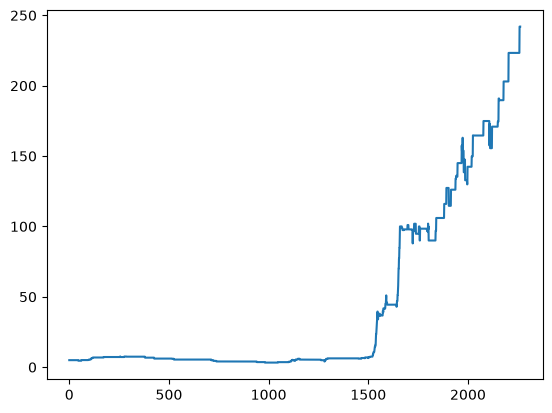

In [2]:
import matplotlib.pyplot as plt

plt.plot(transcohot['close_price'])
plt.show()

In [3]:
transcohot_end_month_df = (
    transcohot
    .sort_values("date")
    .groupby(transcohot["date"].dt.to_period("M"))
    .tail(1)
    .reset_index(drop=True)
)

transcohot_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,45429,TRANSCOHOT,2017-01-31,4.98,4.98,20000,2026-04-08T02:43:03.07753+00:00,1,1,2017
1,47252,TRANSCOHOT,2017-02-28,4.98,4.98,0,2026-04-08T02:44:45.006295+00:00,2,1,2017
2,49368,TRANSCOHOT,2017-03-31,5.04,5.04,1850,2026-04-08T02:45:42.281198+00:00,3,1,2017
3,51195,TRANSCOHOT,2017-04-28,5.04,5.04,0,2026-04-08T02:51:55.619599+00:00,4,2,2017
4,53118,TRANSCOHOT,2017-05-31,5.40,5.40,0,2026-04-08T02:52:57.421655+00:00,5,2,2017
...,...,...,...,...,...,...,...,...,...,...
110,35376,TRANSCOHOT,2026-03-31,203.00,203.00,11984,2026-03-31T15:00:02.085058+00:00,3,1,2026
111,281202,TRANSCOHOT,2026-04-30,223.30,223.30,30004,2026-04-30T15:00:02.170664+00:00,4,2,2026
112,284268,TRANSCOHOT,2026-05-29,223.30,223.30,10751,2026-05-29T15:00:02.455558+00:00,5,2,2026
113,294196,TRANSCOHOT,2026-06-30,223.30,223.30,13675,2026-06-30T15:10:03.08168+00:00,6,2,2026


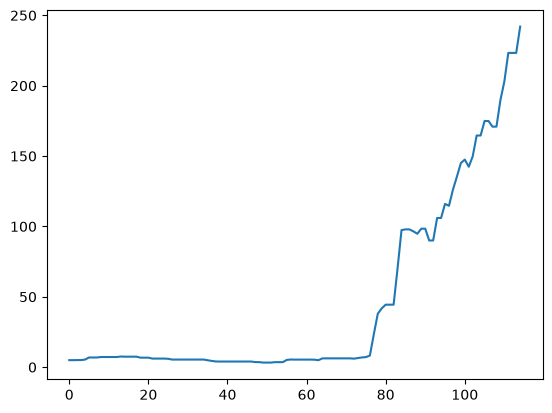

In [4]:
plt.plot(transcohot_end_month_df['close_price'])
plt.show()

In [5]:
transcohot_end_month_df['returns']=transcohot_end_month_df['close_price'].pct_change()*100
transcohot_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year,returns
0,45429,TRANSCOHOT,2017-01-31,4.98,4.98,20000,2026-04-08T02:43:03.07753+00:00,1,1,2017,NaN
1,47252,TRANSCOHOT,2017-02-28,4.98,4.98,0,2026-04-08T02:44:45.006295+00:00,2,1,2017,0.000000
2,49368,TRANSCOHOT,2017-03-31,5.04,5.04,1850,2026-04-08T02:45:42.281198+00:00,3,1,2017,1.204819
3,51195,TRANSCOHOT,2017-04-28,5.04,5.04,0,2026-04-08T02:51:55.619599+00:00,4,2,2017,0.000000
4,53118,TRANSCOHOT,2017-05-31,5.40,5.40,0,2026-04-08T02:52:57.421655+00:00,5,2,2017,7.142857
...,...,...,...,...,...,...,...,...,...,...,...
110,35376,TRANSCOHOT,2026-03-31,203.00,203.00,11984,2026-03-31T15:00:02.085058+00:00,3,1,2026,7.011070
111,281202,TRANSCOHOT,2026-04-30,223.30,223.30,30004,2026-04-30T15:00:02.170664+00:00,4,2,2026,10.000000
112,284268,TRANSCOHOT,2026-05-29,223.30,223.30,10751,2026-05-29T15:00:02.455558+00:00,5,2,2026,0.000000
113,294196,TRANSCOHOT,2026-06-30,223.30,223.30,13675,2026-06-30T15:10:03.08168+00:00,6,2,2026,0.000000


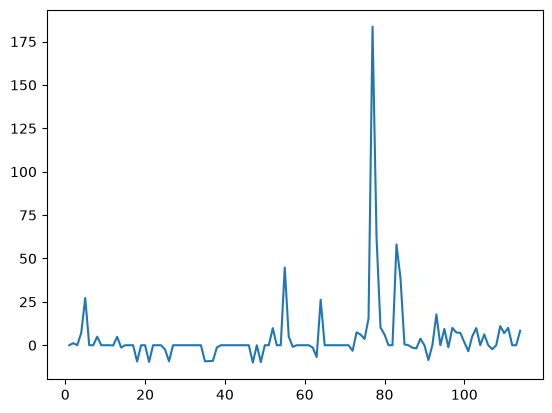

In [6]:
plt.plot(transcohot_end_month_df['returns'])
plt.show()

In [7]:
## Test stationarity

from statsmodels.tsa.stattools import adfuller

result = adfuller(transcohot_end_month_df['returns'].dropna())
print(result)
pvalue = result[1]
if pvalue < 0.05:
    print('stationary')
else:
    print('not stationary')

(np.float64(-7.409258757980072), np.float64(7.206344544009113e-11), 0, 113, {'1%': np.float64(-3.489589552580676), '5%': np.float64(-2.887477210140433), '10%': np.float64(-2.580604145195395)}, np.float64(887.2236899683888))
stationary


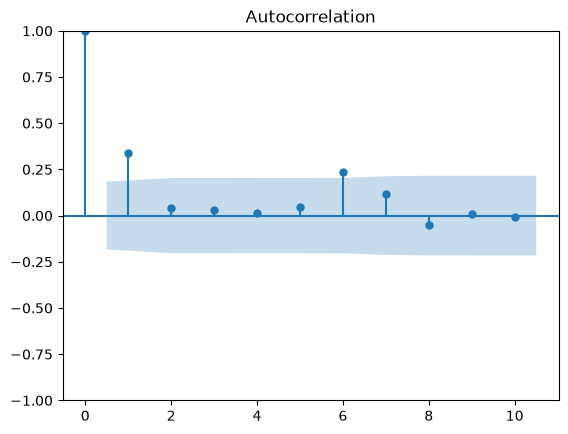

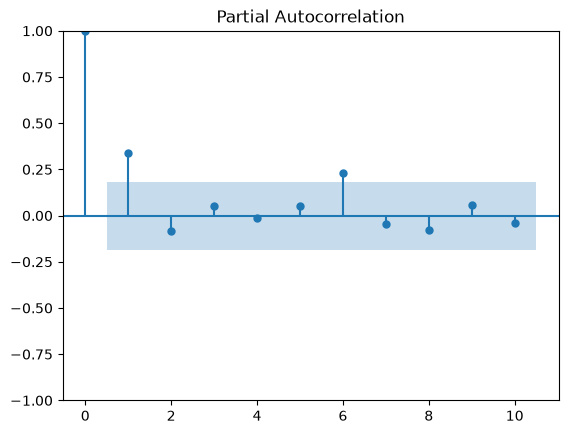

In [8]:
# Plotting the autocorrelation function and the partial autocorrelation function
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(transcohot_end_month_df['returns'].dropna(), lags=10)
plot_pacf(transcohot_end_month_df['returns'].dropna(), lags=10)
plt.show()

In [9]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=transcohot_end_month_df['close_price'][:-10]
test=transcohot_end_month_df['close_price'][-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -61.684854200245326]
[0, 0, 0, 0, 0, 1, -32.36755009058729]
[0, 0, 0, 0, 0, 2, -19.970904721544493]
[0, 0, 0, 0, 1, 0, -6.928251368894772]
[0, 0, 0, 0, 1, 1, -5.979049802440933]
[0, 0, 0, 0, 1, 2, -2.2846876948248735]
[0, 0, 0, 0, 2, 0, -0.28834693301281744]
[0, 0, 0, 0, 2, 1, 0.020862861637895858]
[0, 0, 0, 0, 2, 2, 0.7891729003222825]
[0, 0, 0, 1, 0, 0, -9.53083368522374]
[0, 0, 0, 1, 0, 1, -9.783428400441188]
[0, 0, 0, 1, 0, 2, -6.448735673204154]
[0, 0, 0, 1, 1, 0, -2.274808818592189]
[0, 0, 0, 1, 1, 1, -2.0554116653290184]
[0, 0, 0, 1, 1, 2, -1.0489691606135403]
[0, 0, 0, 1, 2, 0, 0.4637738432441343]
[0, 0, 0, 1, 2, 1, 0.624911555930999]
[0, 0, 0, 1, 2, 2, 0.7818857928781708]
[0, 0, 0, 2, 0, 0, -5.152017133481247]
[0, 0, 0, 2, 0, 1, -6.358159834592602]
[0, 0, 0, 2, 0, 2, -5.433587895097323]
[0, 0, 0, 2, 1, 0, -1.9472043781095487]
[0, 0, 0, 2, 1, 1, -1.4981216636918693]
[0, 0, 0, 2, 1, 2, -1.0749917267647287]
[0, 0, 0, 2, 2, 0, 0.699132808413867]
[0, 0, 0, 2, 2, 

In [10]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
0,0,0,0,0,0,0,-61.684854
27,0,0,1,0,0,0,-58.761891
54,0,0,2,0,0,0,-56.159179
1,0,0,0,0,0,1,-32.367550
28,0,0,1,0,0,1,-31.220418
...,...,...,...,...,...,...,...
462,1,2,2,0,1,0,0.853896
574,2,1,0,0,2,1,0.853972
601,2,1,1,0,2,1,0.854138
709,2,2,2,0,2,1,0.863567


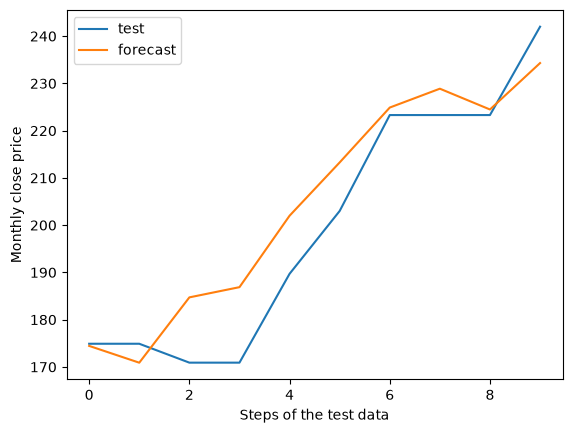

r2_score:  0.8741102535343318
rmse:  9.01799436138309
description:  count    115.000000
mean      45.307217
std       65.658088
min        3.250000
25%        5.380000
50%        6.500000
75%       92.395000
max      242.000000
Name: close_price, dtype: float64


In [11]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

y_train=transcohot_end_month_df['close_price'][:-10]
y_test=transcohot_end_month_df['close_price'][-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(2,2,1), 
seasonal_order=(0,2,1,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly close price')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', transcohot_end_month_df.close_price.describe())

Excellent.